# Handling the Flight Phase

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re

In [2]:
# Using custom funciton from Michael Albert's class

def summarize_dataframe(df):
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")

In [ ]:
full = pd.read_csv('02_Data_Cleaning/Raw_Input_Files/asrs_full.csv.gz')

In [4]:
fp = full.flight_phase.astype(str)

In [5]:
fp

0               Landing
1                Cruise
2                Cruise
3        Final Approach
4                   nan
              ...      
33718             Climb
33719    Final Approach
33720    Final Approach
33721              Taxi
33722               nan
Name: flight_phase, Length: 33723, dtype: object

## Finding out how many and what are the unique values

In [6]:
disagg_fp = []
for phrase in fp:
    disagg_fp.extend([s.strip() for s in re.split(r';', phrase)])

In [7]:
disagg_fp[:30]

['Landing',
 'Cruise',
 'Cruise',
 'Final Approach',
 'nan',
 'Parked',
 'Climb',
 'Initial Approach',
 'Initial Approach',
 'Initial Climb',
 'Landing',
 'Cruise',
 'nan',
 'Takeoff / Launch',
 'Descent',
 'Initial Approach',
 'Initial Approach',
 'Cruise',
 'Cruise',
 'Taxi',
 'Initial Approach',
 'Landing',
 'Initial Approach',
 'Landing',
 'Final Approach',
 'Landing',
 'Taxi',
 'Final Approach',
 'Descent',
 'Taxi']

In [8]:
len(set(disagg_fp))

144

In [9]:
disagg_fp = pd.Series(disagg_fp)

In [10]:
value_counts = disagg_fp.value_counts().reset_index()
value_counts.columns = ["Phase", "Count"]

In [11]:
with pd.option_context('display.max_rows', None):
    display(value_counts)

,Phase,Count
0,Cruise,5402
1,Taxi,3868
2,Parked,3649
3,Climb,3636
4,Initial Approach,3533
5,Final Approach,3150
6,Landing,3033
7,Descent,2917
8,Takeoff / Launch,2802
9,Initial Climb,2158


/tmp/ipykernel_1298/1743949128.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


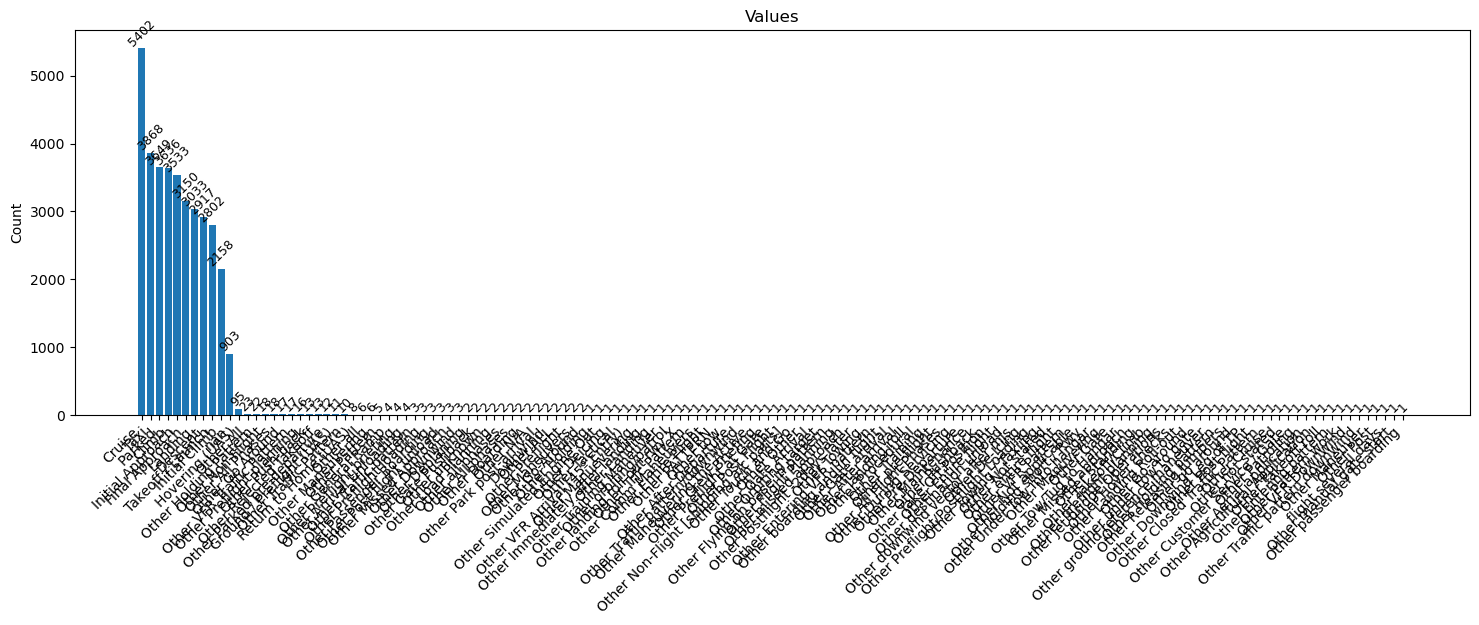

In [12]:
x = value_counts['Phase']
y = value_counts['Count']

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x,y)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=9, rotation =45
    )

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Values')
ax.set_ylabel('Count')
plt.show()

In [ ]:
#value_counts.to_csv('phase_counts.csv',index=False)

## Aggregating Other

In [14]:
# create a copy of the data
dummy_full = full.copy()

dummy_full['flight_phase']=dummy_full['flight_phase'].fillna('nan')

# Making sure to cut out anything from the others list that is not marked 'other'
others = list(value_counts['Phase'][12:])
others = [x for x in others if x not in ['Ground / Preflight (UAS)', 'Return to Home (UAS)']]
others_sorted = sorted(others, key=len, reverse=True)

for value in others_sorted:
    dummy_full['flight_phase'] = dummy_full['flight_phase'].str.replace(value, 'other', regex=False)

In [15]:
# Listing all the raw values in flight phase now - should see some "other" sprinkled in there
with pd.option_context('display.max_rows', None):
    display(dummy_full['flight_phase'].value_counts())

flight_phase
Cruise                                                                5064
Taxi                                                                  3683
Parked                                                                3469
Initial Approach                                                      3206
Climb                                                                 3083
Final Approach                                                        2805
Landing                                                               2759
Descent                                                               2603
Takeoff / Launch                                                      2525
Initial Climb                                                         1647
nan                                                                    903
other                                                                  341
Climb; Initial Climb                                                   240
Final Approa

In [16]:
# Let's check the basic unit values for the column, and compare to what we had above

disagg_fp2 = []
for phrase in dummy_full['flight_phase']:
    disagg_fp2.extend([s.strip() for s in re.split(r';', phrase)])

disagg_fp2 = pd.Series(disagg_fp2)

value_counts2 = disagg_fp2.value_counts().reset_index()
value_counts2.columns = ["Phase", "Count"]

with pd.option_context('display.max_rows', None):
    display(value_counts2)

,Phase,Count
0,Cruise,5402
1,Taxi,3868
2,Parked,3649
3,Climb,3636
4,Initial Approach,3533
5,Final Approach,3150
6,Landing,3033
7,Descent,2917
8,Takeoff / Launch,2802
9,Initial Climb,2158


## Getting Dummy Columns the Easy Way

In [17]:
dummy_full['flight_phase'] = dummy_full['flight_phase'].str.replace(' ', '', regex=False)
dummies = dummy_full['flight_phase'].str.get_dummies(sep=';')
dummy_full = pd.concat([full.copy(), dummies], axis=1)

In [18]:
with pd.option_context('display.max_rows', None):
    display(summarize_dataframe(dummy_full))

/tmp/ipykernel_1298/1810182620.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
anomaly_code,object,0,6664,33723.0,6664,Aircraft Equipment Problem Critical,1974,,,,,,,
location_id,object,0,1903,33723.0,1903,ZZZ.Airport,15229,,,,,,,
aircraft_type,object,35,554,33688.0,554,Commercial Fixed Wing,4791,,,,,,,
reporter_function,object,284,563,33439.0,563,Captain; Pilot Flying,4760,,,,,,,
flight_phase,object,903,347,32820.0,347,Cruise,5064,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0


In [19]:
summarize_dataframe(dummy_full)

/tmp/ipykernel_1298/1810182620.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
anomaly_code,object,0,6664,33723.0,6664,Aircraft Equipment Problem Critical,1974,,,,,,,
location_id,object,0,1903,33723.0,1903,ZZZ.Airport,15229,,,,,,,
aircraft_type,object,35,554,33688.0,554,Commercial Fixed Wing,4791,,,,,,,
reporter_function,object,284,563,33439.0,563,Captain; Pilot Flying,4760,,,,,,,
flight_phase,object,903,347,32820.0,347,Cruise,5064,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0


In [20]:
dummy_full.head(30)

,acn,event_date,anomaly_code,location_id,aircraft_type,reporter_function,flight_phase,narrative_text,synopsis,word_count,...,Hovering(UAS),InitialApproach,InitialClimb,Landing,Parked,ReturntoHome(UAS),Takeoff/Launch,Taxi,nan,other
0,1507557,2018-01-01,ATC Issue All Types; Deviation / Discrepancy -...,C90.TRACON,A330,Approach,Landing,Aircraft X was assigned a runway approximately...,MLI Approach Controller reported ATC denied th...,143,...,0,0,0,1,0,0,0,0,0,0
1,1513720,2018-01-01,Aircraft Equipment Problem Less Severe,ZZZ.Airport,EMB ERJ 170/175 ER/LR,Captain; Pilot Not Flying,Cruise,Pack 2 was MELed. My FO (First Officer) and I ...,ERJ-175 Captain reported diverting after exper...,318,...,0,0,0,0,0,0,0,0,0,0
2,1513718,2018-01-01,Flight Deck / Cabin / Aircraft Event Illness /...,ZZZ.ARTCC,A321,Pilot Not Flying,Cruise,[A passenger] was reported as being ill and un...,A321 flight crew member reported difficulty re...,166,...,0,0,0,0,0,0,0,0,0,0
3,1513706,2018-01-01,Aircraft Equipment Problem Critical,ZZZ.Airport,Citation V/Ultra/Encore (C560),First Officer; Pilot Flying,Final Approach,While on approach at 1;500ft; we asked the tow...,CE-560 First Officer reported that while on ap...,268,...,0,0,0,0,0,0,0,0,0,0
4,1513663,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,RCTP.Airport,B747-400,Pilot Flying; Captain,NaN,Our aircraft had just finished a 'heavy' maint...,B747-400 Captain reported a loss of hydraulic ...,190,...,0,0,0,0,0,0,0,0,1,0
5,1513655,2018-01-01,Deviation / Discrepancy - Procedural Published...,YSSY.Airport,Large Transport; Low Wing; 2 Turbojet Eng,Pilot Not Flying; Captain,Parked,Had printed; acknowledged and signed Release 1...,Air carrier Captain reported a breakdown in co...,334,...,0,0,0,0,1,0,0,0,0,0
6,1513614,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,ZZZ.Airport,B737-700,First Officer; Pilot Flying,Climb,Climbing out on the Departure; the FO (First O...,B737-700 flight crew reported overshooting the...,130,...,0,0,0,0,0,0,0,0,0,0
7,1513606,2018-01-01,ATC Issue All Types; Conflict Airborne Conflic...,MWH.Tower,Globemaster (C-17),Approach; Departure; Supervisor / CIC,Initial Approach,I was working CIC (Controller In Charge) along...,MWH Tower Cab Radar Controller In Charge repor...,631,...,0,1,0,0,0,0,0,0,0,0
8,1513600,2018-01-01,Deviation / Discrepancy - Procedural Published...,ZZZ.Airport,A330,Flight Attendant (On Duty),Initial Approach; Initial Climb,On takeoff I smelled fumes that had a sweet ch...,A330 cabin crew reported smelling an odd odor ...,221,...,0,1,1,0,0,0,0,0,0,0
9,1513569,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,SLE.Airport,Baron 58/58TC,Pilot Flying; Captain,Landing,Lack of runway control after landing Runway 16...,GA pilot reported loss of directional control ...,41,...,0,0,0,1,0,0,0,0,0,0
